In [4]:
import random
import Levenshtein
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch import nn
from sklearn.metrics import f1_score


In [5]:
def generate_genome(length):
    bases = ['A', 'T', 'C', 'G']
    genome_sequence = ''.join(random.choice(bases) for _ in range(length))
    return genome_sequence

def random_mutations(genome_sequence, mutation_rate):
    bases = ['A', 'T', 'C', 'G']
    mutated_sequence = []

    for base in genome_sequence:
        if random.random() < mutation_rate:
            # Mutate the base to a different random base
            new_base = random.choice([b for b in bases if b != base])
            mutated_sequence.append(new_base)
        else:
            # Keep the original base
            mutated_sequence.append(base)
    
    return ''.join(mutated_sequence)

def generate_genome_seed(length, seed):
    random.seed(seed)
    bases = ['A', 'T', 'C', 'G']
    genome_sequence = ''.join(random.choice(bases) for _ in range(length))
    return genome_sequence

random.seed(42)

def replace_N_with_random(sequence):
    symbols = ['A', 'C', 'T', 'G']
    return ''.join(random.choice(symbols) if base == 'N' else base for base in sequence)

def replace_N_in_sequences(sequences):
    return [replace_N_with_random(seq) for seq in sequences]

def kmer_to_index(kmer):
    """Converts a kmer (string) to an index."""
    base_to_index = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    index = 0
    for char in kmer:
        index = 4 * index + base_to_index[char]
    return index

def subkmer_frequencies_in_kmer(kmer, subkmer_length):
    """Calculates the frequency of each subkmer in a kmer."""
    subkmer_counts = Counter(kmer[i:i+subkmer_length] for i in range(len(kmer) - subkmer_length + 1))
    frequencies = np.zeros(4**subkmer_length)
    for subkmer, count in subkmer_counts.items():
        index = kmer_to_index(subkmer)
        frequencies[index] = count
    return frequencies

def frequency_tensor(sequence, kmer_length, subkmer_length, step_size=1):
    """Creates a 2D tensor of subkmer frequencies for each kmer in the sequence with a specified step size."""
    num_kmers = (len(sequence) - kmer_length) // step_size + 1
    tensor = np.zeros((num_kmers, 4**subkmer_length))
    
    for i in range(0, len(sequence) - kmer_length + 1, step_size):
        kmer = sequence[i:i+kmer_length]
        frequencies = subkmer_frequencies_in_kmer(kmer, subkmer_length)
        tensor[i // step_size, :] = frequencies
        
    return tensor

def fidelity(vector1, vector2):
    fidelity = np.abs(np.sum(vector1 * np.conj(vector2)))
    return fidelity

def split_string(s, chunk_size):
    splitted = [s[i:i+chunk_size] for i in range(0, len(s), chunk_size)]
    if len(splitted[-1]) != 100:
        return splitted[:-1]
    return splitted


kmer = 5
subkmer = 2
seq_len = 100
step_size = 2

train set

In [6]:
n_mutations = 1
base_genomes_train = split_string(generate_genome_seed(1000000, 42), 100)

lev_dist_train = []
seqs_list_train = []
base_genomes_train_for_pairs = []
for base_genome_train in base_genomes_train:
    for _ in range(n_mutations):
        mutation = random_mutations(base_genome_train, 0.05)
        seqs_list_train.append(mutation)
        lev_dist_train.append(Levenshtein.distance(base_genome_train, mutation))
        base_genomes_train_for_pairs.append(base_genome_train)
    
rand_genomes = []
rand_genomes_lev = []
for base_genome_train in base_genomes_train: 
    for _ in range(n_mutations):
        rand_genome = generate_genome(seq_len)
        rand_genomes.append(rand_genome)
        rand_genomes_lev.append(Levenshtein.distance(base_genome_train, rand_genome))
        base_genomes_train_for_pairs.append(base_genome_train)


seqs_list_train.extend(rand_genomes)
targets_list_train = [0 for _ in range(n_mutations*len(base_genomes_train))] + [1 for _ in range(n_mutations*len(base_genomes_train))]
lev_dist_train.extend(rand_genomes_lev)

validation set

In [7]:

n_mutations = 1
base_genomes_val = split_string(generate_genome_seed(100000, 43), 100)
lev_dist_val = []
seqs_list_val = []
base_genomes_val_for_pairs = []
for base_genome_val in base_genomes_val:
    for _ in range(n_mutations):
        mutation = random_mutations(base_genome_val, 0.05)
        seqs_list_val.append(mutation)
        lev_dist_val.append(Levenshtein.distance(base_genome_val, mutation))
        base_genomes_val_for_pairs.append(base_genome_val)
    
rand_genomes = []
rand_genomes_lev = []
for base_genome_val in base_genomes_val: 
    for _ in range(n_mutations):
        rand_genome = generate_genome(seq_len)
        rand_genomes.append(rand_genome)
        rand_genomes_lev.append(Levenshtein.distance(base_genome_val, rand_genome))
        base_genomes_val_for_pairs.append(base_genome_val)


seqs_list_val.extend(rand_genomes)
targets_list_val = [0 for _ in range(n_mutations*len(base_genomes_val))] + [1 for _ in range(n_mutations*len(base_genomes_val))]
lev_dist_val.extend(rand_genomes_lev)

In [8]:
base_tensors_train = [torch.from_numpy(frequency_tensor(base_genome_train, kmer, subkmer, step_size)).type(torch.float) / (kmer - 1) for base_genome_train in base_genomes_train_for_pairs]
base_tensors_val = [torch.from_numpy(frequency_tensor(base_genome_val, kmer, subkmer, step_size)).type(torch.float) / (kmer - 1) for base_genome_val in base_genomes_val_for_pairs]
seqs_tensors_train = [torch.from_numpy(frequency_tensor(seq, kmer, subkmer, step_size)).type(torch.float) / (kmer - 1) for seq in seqs_list_train]
seqs_tensors_val = [torch.from_numpy(frequency_tensor(seq, kmer, subkmer, step_size)).type(torch.float) / (kmer - 1) for seq in seqs_list_val]

conv model

In [9]:
class EditDistanceModel(nn.Module):
    def __init__(self):
        super(EditDistanceModel, self).__init__()
        
        self.flatten = nn.Flatten()
        
        self.conv1_real = nn.Conv1d(1, 1, kernel_size=2, stride=1, padding=0)
        self.conv1_imag = nn.Conv1d(1, 1, kernel_size=2, stride=1, padding=0)
        self.conv2_real = nn.Conv1d(2, 4, kernel_size=2, stride=2, padding=0)
        self.conv2_imag = nn.Conv1d(2, 4, kernel_size=2, stride=2, padding=0)
        
        # Calculate the flattened dimension after the conv layers
        # self.flatten_dim = 1552
        # self.flatten_dim = 1551 #k=4, step=1
        # self.flatten_dim = 783 #k=4, step=2
        # self.flatten_dim = 1535 #k=5, step=1
        self.flatten_dim = 767 #k=4, step=2

        # self.flatten_dim = 1295 #step = 1, k = 20
        # self.flatten_dim = 271 #step = 5, k = 20
        # self.flatten_dim = 143 #step = 10
        # self.flatten_dim = 95 #step = 15
        # self.flatten_dim = 79 #step = 20
        # self.flatten_dim = 47 #k = 50, step = 20
        # self.flatten_dim = 31 #k = 50, step = 50
        # self.flatten_dim = 15 #k = 100, step = 100

        self.fc_real = nn.Linear(self.flatten_dim, 1024)
        self.fc_imag = nn.Linear(self.flatten_dim, 1024)
        

    def forward(self, x1, x2):
        
        # Flatten the embeddings
        x1 = self.flatten(x1)
        x2 = self.flatten(x2)
        
        # Reshape to (batch_size, 1, embedding_dim * len_dim) for Conv1d
        x1 = x1.unsqueeze(1)
        x2 = x2.unsqueeze(1)
        
        x1_real = F.relu(self.conv1_real(x1))
        x1_imag = F.relu(self.conv1_imag(x1))
        x2_real = F.relu(self.conv1_real(x2))
        x2_imag = F.relu(self.conv1_imag(x2))
        
        # x1_real = F.relu(self.conv2_real(x1_real))
        # x1_imag = F.relu(self.conv2_imag(x1_imag))
        # x2_real = F.relu(self.conv2_real(x2_real))
        # x2_imag = F.relu(self.conv2_imag(x2_imag))
        
        # Flatten the output of the convolutional layers
        x1_real = self.flatten(x1_real)
        x1_imag = self.flatten(x1_imag)
        x2_real = self.flatten(x2_real)
        x2_imag = self.flatten(x2_imag)
        
        x1_real = self.fc_real(x1_real)
        x1_imag = self.fc_imag(x1_imag)
        x2_real = self.fc_real(x2_real)
        x2_imag = self.fc_imag(x2_imag)
        
        x1 = torch.complex(x1_real, x1_imag)
        x2 = torch.complex(x2_real, x2_imag)
        
        # Normalize the output vectors to have a norm of 1
        x1 = x1 / torch.norm(x1, dim=-1, keepdim=True)
        x2 = x2 / torch.norm(x2, dim=-1, keepdim=True)
        
        return x1, x2

In [10]:
class EditDistanceDataset(Dataset):
    def __init__(self, input_pairs, targets):
        self.input_pairs = input_pairs
        self.targets = targets

    def __len__(self):
        return len(self.input_pairs)

    def __getitem__(self, idx):
        return self.input_pairs[idx], self.targets[idx]
    
input_pairs_train = []
for i in range(len(base_tensors_train)):
    input_pairs_train.append((base_tensors_train[i], seqs_tensors_train[i]))
input_pairs_val = []
for i in range(len(seqs_tensors_val)):
    input_pairs_val.append((base_tensors_val[i], seqs_tensors_val[i]))

targets_train = targets_list_train
targets_val = targets_list_val

train_dataset = EditDistanceDataset(input_pairs_train, targets_train)
train_dataloader = DataLoader(train_dataset, batch_size=5, shuffle=True)

val_dataset = EditDistanceDataset(input_pairs_val, targets_val)
val_dataloader = DataLoader(val_dataset, batch_size=5, shuffle=False)

criterion = nn.BCELoss()

def fidelity_loss(output1, output2, target):
    fidelity = 1 - torch.abs(torch.sum(output1 * torch.conj(output2), dim=-1))
    fidelity = torch.clamp(fidelity, 0, 1)
    loss = criterion(fidelity, target)
    return loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = EditDistanceModel()  
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)


training

In [8]:
num_epochs = 10
model.train()

for epoch in range(num_epochs):
    # Training phase
    model.train()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    all_targets = []
    all_predictions = []
    
    for batch in train_dataloader:
        input_pairs, targets = batch
        input1, input2 = input_pairs
        input1 = input1.to(device)
        input2 = input2.to(device)
        targets = targets.clone().detach().float().to(device)
        
        optimizer.zero_grad()
        output1, output2 = model(input1, input2)
        loss = fidelity_loss(output1, output2, targets)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Calculate predictions
        fidelity_value = 1 - torch.abs(torch.sum(output1 * torch.conj(output2), dim=-1))
        predicted = (fidelity_value > 0.5).float()
        
        # Update accuracy metrics
        correct_predictions += (predicted == targets).sum().item()
        total_samples += targets.size(0)
        
        # Store predictions and targets for F1 score calculation
        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())
    
    avg_loss = total_loss / len(train_dataloader)
    train_accuracy = correct_predictions / total_samples * 100
    train_f1 = f1_score(all_targets, all_predictions)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {avg_loss:.4f}, '
          f'Training Accuracy: {train_accuracy:.2f}%, Training F1 Score: {train_f1:.2f}')
    
    # Validation phase
    model.eval()
    val_total_loss = 0
    val_correct_predictions = 0
    val_total_samples = 0
    val_all_targets = []
    val_all_predictions = []
    
    with torch.no_grad():
        for batch in val_dataloader:
            input_pairs, targets = batch
            input1, input2 = input_pairs
            input1 = input1.to(device)
            input2 = input2.to(device)
            targets = targets.clone().detach().float().to(device)
            
            output1, output2 = model(input1, input2)
            val_loss = fidelity_loss(output1, output2, targets)
            val_total_loss += val_loss.item()
            
            # Calculate predictions
            fidelity_value = 1 - torch.abs(torch.sum(output1 * torch.conj(output2), dim=-1))
            predicted = (fidelity_value > 0.5).float()
            
            # Update accuracy metrics
            val_correct_predictions += (predicted == targets).sum().item()
            val_total_samples += targets.size(0)
            
            # Store predictions and targets for F1 score calculation
            val_all_targets.extend(targets.cpu().numpy())
            val_all_predictions.extend(predicted.cpu().numpy())
    
    val_avg_loss = val_total_loss / len(val_dataloader)
    val_accuracy = val_correct_predictions / val_total_samples * 100
    val_f1 = f1_score(val_all_targets, val_all_predictions)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_avg_loss:.4f}, '
          f'Validation Accuracy: {val_accuracy:.2f}%, Validation F1 Score: {val_f1:.2f}')


Epoch [1/10], Training Loss: 0.1297, Training Accuracy: 98.52%, Training F1 Score: 0.98
Epoch [1/10], Validation Loss: 0.1032, Validation Accuracy: 100.00%, Validation F1 Score: 1.00
Epoch [2/10], Training Loss: 0.0928, Training Accuracy: 100.00%, Training F1 Score: 1.00
Epoch [2/10], Validation Loss: 0.1024, Validation Accuracy: 99.95%, Validation F1 Score: 1.00
Epoch [3/10], Training Loss: 0.0808, Training Accuracy: 100.00%, Training F1 Score: 1.00
Epoch [3/10], Validation Loss: 0.1015, Validation Accuracy: 100.00%, Validation F1 Score: 1.00
Epoch [4/10], Training Loss: 0.0741, Training Accuracy: 100.00%, Training F1 Score: 1.00
Epoch [4/10], Validation Loss: 0.1017, Validation Accuracy: 100.00%, Validation F1 Score: 1.00
Epoch [5/10], Training Loss: 0.0695, Training Accuracy: 100.00%, Training F1 Score: 1.00
Epoch [5/10], Validation Loss: 0.0992, Validation Accuracy: 100.00%, Validation F1 Score: 1.00
Epoch [6/10], Training Loss: 0.0665, Training Accuracy: 100.00%, Training F1 Score

In [10]:
# Prepare DataLoaders for inference
inference_train = DataLoader(train_dataset, batch_size=1, shuffle=False)
inference_val = DataLoader(val_dataset, batch_size=1, shuffle=False)

# Ensure model is in evaluation mode and on the CPU
model.eval()
model.to("cpu")

# Initialize lists to store inferred outputs
inferred_train_bases = []
inferred_train = []
inferred_val_bases = []
inferred_val = []

# Inference on training data
with torch.no_grad():
    for batch in inference_train:
        input_pairs, _ = batch  # Targets are not needed for inference
        input1, input2 = input_pairs
        input1 = input1.cpu()
        input2 = input2.cpu()

        output1, output2 = model(input1, input2)

        inferred_train_bases.append(output1.squeeze(0))  # Remove the batch dimension
        inferred_train.append(output2.squeeze(0))

# Inference on validation data
with torch.no_grad():
    for batch in inference_val:
        input_pairs, _ = batch
        input1, input2 = input_pairs
        input1 = input1.cpu()
        input2 = input2.cpu()

        output1, output2 = model(input1, input2)

        inferred_val_bases.append(output1.squeeze(0))
        inferred_val.append(output2.squeeze(0))

# Convert tensors to NumPy arrays
inferred_train = [el.detach().cpu().numpy() for el in inferred_train]
inferred_train_bases = [el.detach().cpu().numpy() for el in inferred_train_bases]
inferred_val = [el.detach().cpu().numpy() for el in inferred_val]
inferred_val_bases = [el.detach().cpu().numpy() for el in inferred_val_bases]

In [11]:
fidelity_train = []
for i in range(len(inferred_train)):
    fidelity_train.append(fidelity(inferred_train_bases[i], inferred_train[i]))
fidelity_val = []
for i in range(len(inferred_val)):
    fidelity_val.append(fidelity(inferred_val_bases[i], inferred_val[i]))

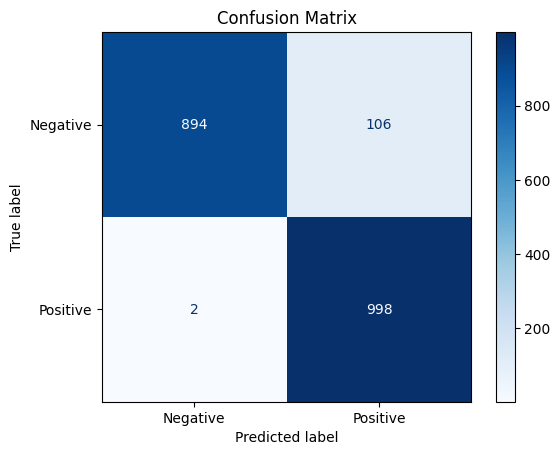

In [12]:
true_labels = []
pred_labels = []

# Populate true_labels and pred_labels based on the given conditions
for fid, lev in zip(fidelity_val, lev_dist_val):
    if fid > 0.5 and lev < 20:
        true_labels.append(1)
        pred_labels.append(1)
    elif fid < 0.5 and lev > 20:
        true_labels.append(0)
        pred_labels.append(0)
    elif fid > 0.5 and lev > 20:
        true_labels.append(0)
        pred_labels.append(1)
    elif fid < 0.5 and lev < 20:
        true_labels.append(1)
        pred_labels.append(0)

# Calculate confusion matrix
conf_matrix = confusion_matrix(true_labels, pred_labels)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

accuracy val

In [13]:
count_correct = 0
for i in range(len(fidelity_val)):
    if (fidelity_val[i] < 0.5 and lev_dist_val[i] > 20) or (fidelity_val[i] > 0.5 and lev_dist_val[i] < 20):
        count_correct += 1
count_correct/ len(fidelity_val)

0.946

dot plot

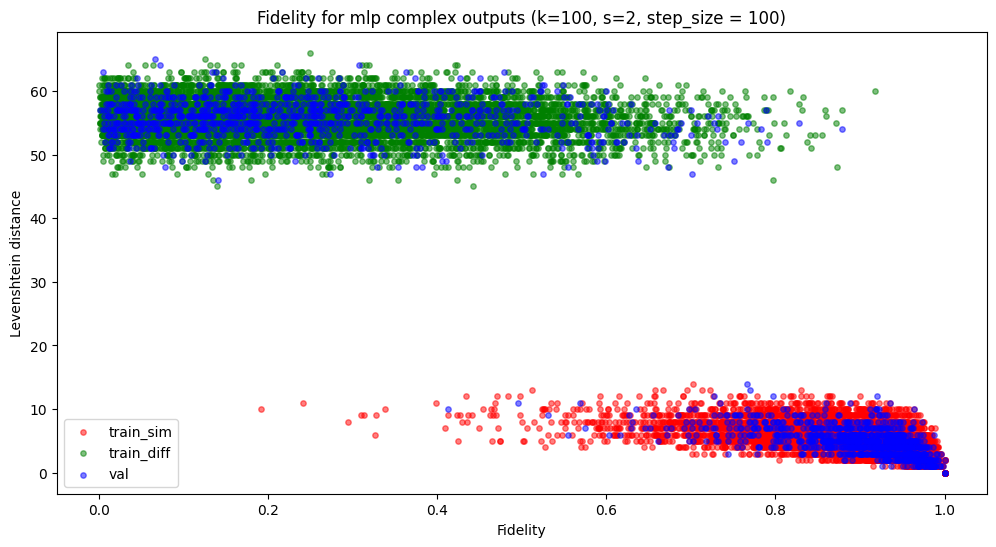

In [14]:
plt.figure(figsize=(12, 6))

dot_size = 15
alpha = 0.5
# First subplot
plt.subplot(1, 1, 1)
plt.scatter(fidelity_train[:n_mutations*len(base_genomes_train)], lev_dist_train[:n_mutations*len(base_genomes_train)], color='red', label='train_sim', s=dot_size, alpha = alpha)
plt.scatter(fidelity_train[n_mutations*len(base_genomes_train):], lev_dist_train[n_mutations*len(base_genomes_train):], color='green', label='train_diff', s=dot_size, alpha = alpha)  
plt.scatter(fidelity_val, lev_dist_val, color='blue', label='val', s=dot_size, alpha = alpha)
plt.title(f'Fidelity for mlp complex outputs (k={kmer}, s={subkmer}, step_size = {step_size})')
plt.xlabel('Fidelity')
plt.ylabel('Levenshtein distance')
plt.legend()